In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#UDI — Eindeutige ID
#Product ID — Produkttyp (L = Low quality, M = Medium, H = High)
#Type — Kürzel L/M/H
#Air temperature [K] — Lufttemperatur in Kelvin
#Process temperature [K] — Prozesstemperatur in Kelvin
#Rotational speed [rpm] — Drehzahl
#orque [Nm] — Drehmoment
#Tool wear [min] — Werkzeugverschleiß in Minuten
#Machine failure — 0/1 Hauptlabel (gab es einen Ausfall?)
#TWF — Tool Wear Failure (Werkzeugverschleiß-Ausfall)
#HDF — Heat Dissipation Failure (Hitzeableitungs-Ausfall)
#PWF — Power Failure (Leistungs-Ausfall)
#OSF — Overstrain Failure (Überlastungs-Ausfall)
#RNF — Random Failure (zufälliger Ausfall)

In [2]:
ai4i_df = pd.read_csv("ai4i2020.csv")

In [3]:
ai4i_df.shape

(10000, 14)

In [4]:
ai4i_df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
ai4i_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [6]:
ai4i_df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
ai4i_df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

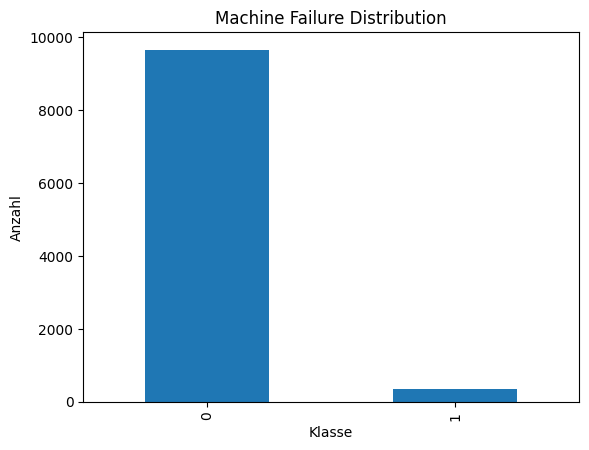

In [8]:
ai_failure = ai4i_df["Machine failure"].value_counts()
ai_failure.plot(kind="bar")
plt.title("Machine Failure Distribution")
plt.xlabel("Klasse")
plt.ylabel("Anzahl")
plt.show()


In [9]:
ai4i_df.groupby("Machine failure")["Tool wear [min]"].mean()

Machine failure
0    106.693717
1    143.781711
Name: Tool wear [min], dtype: float64

In [10]:
ai4i_df.groupby("Machine failure").mean(numeric_only=True)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
Machine failure,,,,,,,,,,,
0,5012.878791,299.973999,309.995570,1540.260014,39.629655,106.693717,0.000000,0.000000,0.000000,0.000000,0.001863
1,4647.722714,300.886431,310.290265,1496.486726,50.168142,143.781711,0.135693,0.339233,0.280236,0.289086,0.002950


In [11]:
corr_matrix = ai4i_df.corr(numeric_only=True)
print(corr_matrix)

                              UDI  Air temperature [K]  \
UDI                      1.000000             0.117428   
Air temperature [K]      0.117428             1.000000   
Process temperature [K]  0.324428             0.876107   
Rotational speed [rpm]  -0.006615             0.022670   
Torque [Nm]              0.003207            -0.013778   
Tool wear [min]         -0.010702             0.013853   
Machine failure         -0.022892             0.082556   
TWF                      0.009154             0.009955   
HDF                     -0.022215             0.137831   
PWF                     -0.023557             0.003470   
OSF                     -0.000990             0.001988   
RNF                     -0.005954             0.017688   

                         Process temperature [K]  Rotational speed [rpm]  \
UDI                                     0.324428               -0.006615   
Air temperature [K]                     0.876107                0.022670   
Process temperatu

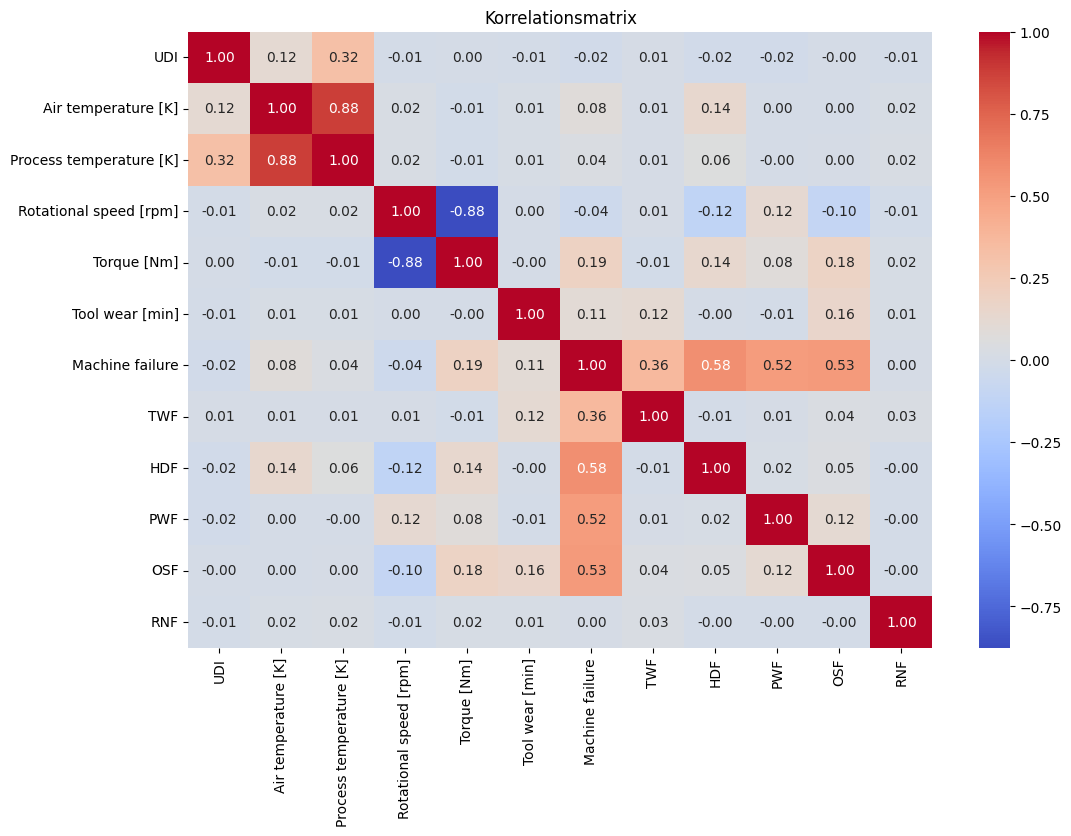

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelationsmatrix")
plt.show()


In [13]:
ai4i_df["Temp_diff"]= ai4i_df["Process temperature [K]"] - ai4i_df["Air temperature [K]"]

In [14]:
ai4i_df[["Air temperature [K]", "Process temperature [K]", "Temp_diff"]].head()

,Air temperature [K],Process temperature [K],Temp_diff
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [15]:
ai4i_df["Temp_diff"].corr(ai4i_df["Machine failure"])

np.float64(-0.11167631166572772)

In [16]:
ai4i_df["Air temperature [K]"].corr(ai4i_df["Machine failure"])
ai4i_df["Process temperature [K]"].corr(ai4i_df["Machine failure"])


np.float64(0.03594597332977694)

In [17]:
ai4i_df.groupby("Machine failure")["Temp_diff"].mean() 

Machine failure
0    10.021571
1     9.403835
Name: Temp_diff, dtype: float64

<Axes: title={'center': 'Torque [Nm]'}, xlabel='Machine failure'>

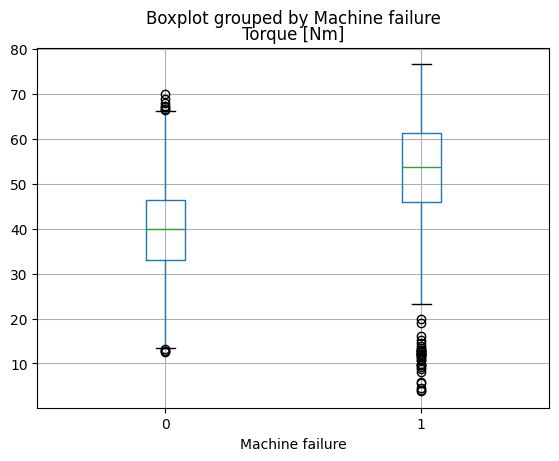

In [18]:
ai4i_df.boxplot(column="Torque [Nm]", by = "Machine failure",)

<Axes: title={'center': 'Tool wear [min]'}, xlabel='Machine failure'>

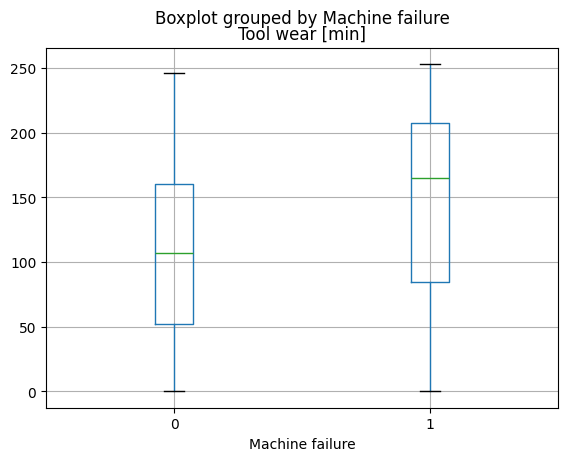

In [19]:
ai4i_df.boxplot(column="Tool wear [min]", by = "Machine failure") 

In [20]:
ai4i_df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [ ]:
ai4i_df["Machine failure"].value_counts()

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

KeyError: ('TWF', 'HDF', 'PWF', 'OSF', 'RNF')

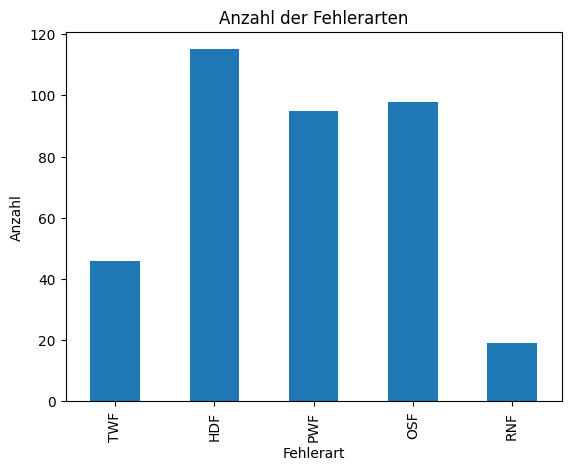

In [27]:
ai4i_df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum().plot(kind="bar")
plt.title("Anzahl der Fehlerarten")
plt.xlabel("Fehlerart")
plt.ylabel("Anzahl")
plt.show()

In [28]:
ai4i_df["Temp_diff"].groupby(ai4i_df["HDF"]).mean()

HDF
0    10.021254
1     8.227826
Name: Temp_diff, dtype: float64

In [31]:
#Alternative
ai4i_df.groupby("HDF")["Temp_diff"].mean()

HDF
0    10.021254
1     8.227826
Name: Temp_diff, dtype: float64

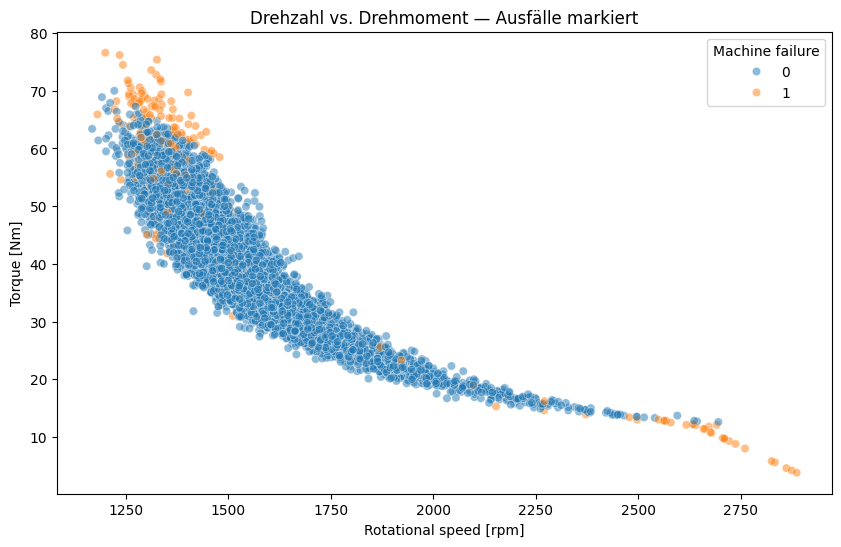

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ai4i_df, x="Rotational speed [rpm]", y="Torque [Nm]", 
                hue="Machine failure", alpha=0.5)
plt.title("Drehzahl vs. Drehmoment — Ausfälle markiert")
plt.show()

In [38]:
ai4i_df["Torque_kategorie"] = pd.cut(ai4i_df["Torque [Nm]"], bins=3, labels = ["niedrig", "mittel", "hoch"])

In [39]:
ai4i_df["Torque_kategorie"].value_counts()

Torque_kategorie
mittel     7788
niedrig    1157
hoch       1055
Name: count, dtype: int64

In [40]:
ai4i_df.groupby("Torque_kategorie")["Machine failure"].mean()

Torque_kategorie
niedrig    0.033708
mittel     0.014510
hoch       0.177251
Name: Machine failure, dtype: float64

In [41]:
ai4i_df["Toolwear_kategorie"] = pd.cut(ai4i_df["Tool wear [min]"], bins=3, labels = ["niedrig", "mittel", "hoch"])

In [42]:
ai4i_df.groupby("Toolwear_kategorie")["Machine failure"].mean()

Toolwear_kategorie
niedrig    0.021568
mittel     0.022983
hoch       0.074439
Name: Machine failure, dtype: float64

In [43]:
ai4i_df.groupby(["Torque_kategorie", "Toolwear_kategorie"])["Machine failure"].mean()

Torque_kategorie  Toolwear_kategorie
niedrig           niedrig               0.029915
                  mittel                0.030445
                  hoch                  0.045802
mittel            niedrig               0.008783
                  mittel                0.007749
                  hoch                  0.036082
hoch              niedrig               0.110276
                  mittel                0.119816
                  hoch                  0.409910
Name: Machine failure, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

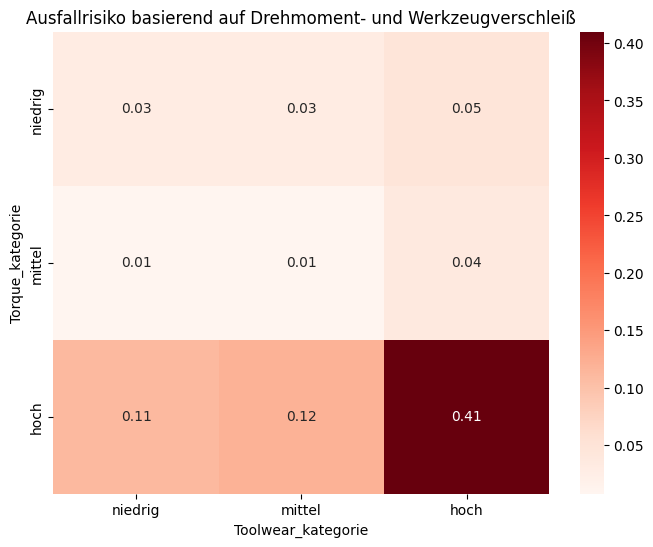

In [45]:
risiko = ai4i_df.groupby(["Torque_kategorie", "Toolwear_kategorie"])["Machine failure"].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(risiko, annot=True, cmap="Reds", fmt=".2f")
plt.title("Ausfallrisiko basierend auf Drehmoment- und Werkzeugverschleiß")
plt.show

In [49]:
ai4i_df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temp_diff', 'Torque_Kategorie', 'Torque_kategorie',
       'Toolwear_kategorie'],
      dtype='str')

In [47]:
ai4i_df.groupby("Type")["Machine failure"].mean()


Type
H    0.020937
L    0.039167
M    0.027694
Name: Machine failure, dtype: float64

In [51]:
ai4i_df["Torque_kategorie"].head()

0    mittel
1    mittel
2    mittel
3    mittel
4    mittel
Name: Torque_kategorie, dtype: category
Categories (3, str): ['niedrig' < 'mittel' < 'hoch']